### Build a Basic Chatbot with LangGraph (Graph API)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    ## add_messages would append inside the list rather replacing them
    messages:Annotated[list,add_messages]

In [4]:
graph_builder=StateGraph(State)

In [5]:
graph_builder

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_groq import ChatGroq

In [8]:
llm=ChatGroq(model='qwen/qwen3-32b')

In [9]:
llm.invoke("hii")

AIMessage(content='<think>\nOkay, the user said "hii". That\'s a friendly greeting. I should respond in a welcoming way. Let me check if there\'s any specific context I need to consider. Since there\'s no history before this, just a simple hello is best. Maybe add an emoji to keep it warm. I should ask how they\'re doing or if there\'s something they need help with. Keep it open-ended so they can decide what to talk about next.\n\nPossible responses:\n1. Hi there! How can I assist you today? 😊\n2. Hello! What\'s on your mind? Let me know how I can help. 🌟\n3. Hey! Happy to see you. Need any assistance? 😊\n\nI think the first one is good because it\'s friendly and offers help directly. Maybe add a smiley to make it more approachable. Yeah, that should work.\n</think>\n\nHi there! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 199, 'prompt_tokens': 10, 'total_tokens': 209, 'completion_time': 0.434289541, 'completion_tokens_de

In [10]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)

graph_builder.add_node("chatbot",chatbot)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph=graph_builder.compile()

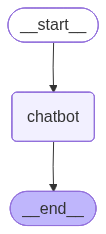

In [12]:
## Visulise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
graph.invoke({"messages":"Hii"})["messages"][-1].content

'<think>\nOkay, the user said "Hii". That\'s a friendly greeting with an extra \'i\'. I should respond in a welcoming manner. Maybe start with a hello and ask how I can assist them. Keep it simple and open-ended so they feel comfortable to ask anything. Let me make sure the tone is positive and helpful.\n</think>\n\nHello! How can I assist you today? 😊'

In [14]:
for event in graph.stream({"messages":"Hi How are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me with "Hi How are you". I should respond warmly and ask about their well-being as well. Since I'm an AI, I don't have feelings, but I can express friendly concern. I need to use a natural, conversational tone without being too formal. I should also consider if they need help with something specific.

The user is asking how I am, which is a common greeting. I should acknowledge their greeting, express that I'm functioning well, and show genuine interest in how they're doing. The response should be concise but not too brief, and maintain a balance between friendliness and professionalism.

Additionally, I should be mindful of cultural differences in greetings. In some cultures, people may be more formal, while in others, they might be more casual. Since I'm an AI, I should maintain a neutral and approachable demeanor.

I should also consider if the user is looking for a deeper conversation or just a polite exchange. If they're open for further discussion,

### Chatbot with tools


In [15]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to 

In [16]:
## Custom function

def multiply(a:int,b:int)->int:
    """
    Multiply a and b

    Args:
        a (int): first number
        b (int): second number
    
    Returns:
        int: output Number
    """
    return a*b;

In [17]:
tools=[tool,multiply]

In [18]:
llm_with_tool=llm.bind_tools(tools)

In [19]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [20]:
builder=StateGraph(State)

In [21]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

In [22]:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

In [23]:
graph=builder.compile()

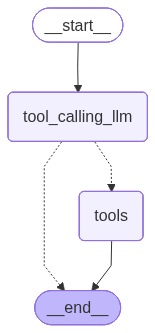

In [24]:
## Visulise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
response=graph.invoke({"messages":"What is the recent AI news"})

In [26]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/06/12/ai-tech-brief-wall-street-rewrites-rules-ai-giants/", "title": "AI & Tech Brief: Wall Street rewrites rules for AI giants - The Washington Post", "score": 0.64746445, "published_date": "Fri, 12 Jun 2026 19:29:38 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Wall Street rewrites rules for AI giants. SpaceX’s IPO shows how major indices are willing to bend the rules for massive companies in the AI era. Make us preferred on Google. Sign up here to get this newsletter in your inbox. * SpaceX stock soared following its Friday debut. But the more interesting story is how major indexes completely redesigned their rules to include the likes of SpaceX, Anthropic and OpenAI. * President Donald Trump said he plans on inviting 12 to 15 CEOs of the AI giants to discuss public ownership of the

In [27]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (k8807j0c7)
 Call ID: k8807j0c7
  Args:
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/06/12/ai-tech-brief-wall-street-rewrites-rules-ai-giants/", "title": "AI & Tech Brief: Wall Street rewrites rules for AI giants - The Washington Post", "score": 0.64746445, "published_date": "Fri, 12 Jun 2026 19:29:38 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Wall Street rewrites rules for AI giants. SpaceX’s IPO shows how major indices are willing to bend the rules f

In [28]:
response=graph.invoke({"messages":"What is 2 multiplied by 3"})

In [29]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (5zeb5r966)
 Call ID: 5zeb5r966
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


### ReAct Agent 

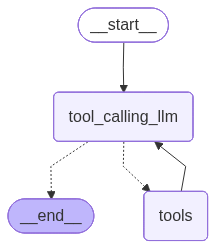

In [30]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder=StateGraph(State)

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")


graph=builder.compile()

## Visulise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [31]:
response=graph.invoke({"messages":"What is the recent AI news"})

In [32]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h641eky2n)
 Call ID: h641eky2n
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wowtale.net/2026/06/13/234244/", "title": "[Korean Startup Weekly News #122] Beyond the Algorithm : AI Meets Industry - Wowtale", "score": 0.60694176, "published_date": "Sat, 13 Jun 2026 05:49:06 GMT", "content": "### R2C Company (Pickply)\n\nBridge funding from HYU Holdings for data collection platform with 500K+ users. University-backed investment highlights growing academic-startup synergy. Read more →\n\n### Evom AI\n\nSeed